# Partie I – MLP et ingénierie PyTorch
## Classification supervisée sur données tabulaires : Breast Cancer Wisconsin
---
**Module :** Deep Learning — EMSI Casablanca 2025–2026  
**Objectif :** Maîtriser nn.Module, la gestion des paramètres, l'initialisation, la sauvegarde et l'utilisation CPU/GPU.

## 0. Configuration Globale
Toutes les constantes et hyperparamètres sont centralisés ici. Modifier ce bloc suffit pour adapter l'expérience.

In [1]:
# ============================================================
# CONFIGURATION GLOBALE – modifier ici pour adapter le projet
# ============================================================
import os

CONFIG = {
    # --- Données ---
    "dataset_source": "kaggle",          # 'kaggle' ou 'local'
    "kaggle_dataset": "uciml/breast-cancer-wisconsin-data",
    "local_csv_path": "data/breast_cancer.csv",
    "target_column": "diagnosis",
    "columns_to_drop": ["id", "Unnamed: 32"],
    "positive_class": "M",               # Malignant

    # --- Split ---
    "test_size": 0.15,
    "val_size": 0.15,
    "random_seed": 42,

    # --- Architecture MLP ---
    "hidden_sizes": [128, 64, 32],
    "dropout_rate": 0.3,
    "activation": "relu",                # 'relu' | 'tanh' | 'leaky_relu'

    # --- Entraînement ---
    "epochs": 100,
    "batch_size": 32,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "optimizer": "adam",                 # 'adam' | 'sgd' | 'rmsprop'
    "scheduler": "step",                 # 'step' | 'cosine' | None
    "scheduler_step_size": 30,
    "scheduler_gamma": 0.5,
    "early_stopping_patience": 15,

    # --- Initialisation ---
    "init_strategies": ["gaussian", "constant", "xavier_uniform"],

    # --- Sauvegarde ---
    "save_dir": "models",
    "best_model_name": "best_mlp.pth",

    # --- Reproductibilité ---
    "seed": 42,
}

os.makedirs(CONFIG["save_dir"], exist_ok=True)
os.makedirs("data", exist_ok=True)
print("Configuration chargée.")
print(f"Paramètres : {CONFIG}")

Configuration chargée.
Paramètres : {'dataset_source': 'kaggle', 'kaggle_dataset': 'uciml/breast-cancer-wisconsin-data', 'local_csv_path': 'data/breast_cancer.csv', 'target_column': 'diagnosis', 'columns_to_drop': ['id', 'Unnamed: 32'], 'positive_class': 'M', 'test_size': 0.15, 'val_size': 0.15, 'random_seed': 42, 'hidden_sizes': [128, 64, 32], 'dropout_rate': 0.3, 'activation': 'relu', 'epochs': 100, 'batch_size': 32, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'optimizer': 'adam', 'scheduler': 'step', 'scheduler_step_size': 30, 'scheduler_gamma': 0.5, 'early_stopping_patience': 15, 'init_strategies': ['gaussian', 'constant', 'xavier_uniform'], 'save_dir': 'models', 'best_model_name': 'best_mlp.pth', 'seed': 42}


## 1. Étude Théorique
### 1.1 Fondements : nn.Module, paramètres, gradients, state_dict, device

**nn.Module** est la classe de base de tous les modèles PyTorch. Elle gère automatiquement :
- les **paramètres apprenables** (poids, biais) via `nn.Parameter`
- le **forward pass** à définir dans `forward()`
- le **backward pass** via l'autograd (graphe de calcul dynamique)
- la **sauvegarde** via `state_dict()`
- le **déplacement GPU/CPU** via `.to(device)`

**Gradient** : Pour un paramètre $\theta$, le gradient $\nabla_{\theta} \mathcal{L}$ est calculé automatiquement par `loss.backward()`.  
**Mise à jour** : $\theta \leftarrow \theta - \eta \cdot \nabla_{\theta} \mathcal{L}$

**state_dict** : dictionnaire `{nom_param: tenseur}` — format standard de persistance.

**Device** : `torch.device('cuda')` si GPU disponible, sinon `'cpu'`. Modèle et données doivent être sur le même device.

### 1.2 Propagation avant et rétropropagation

Pour un MLP à $L$ couches :
$$h^{(0)} = x, \quad h^{(l)} = \sigma(W^{(l)} h^{(l-1)} + b^{(l)}), \quad \hat{y} = \text{softmax}(W^{(L)} h^{(L-1)} + b^{(L)})$$

La rétropropagation calcule $\frac{\partial \mathcal{L}}{\partial W^{(l)}}$ par la règle de la chaîne, de la sortie vers l'entrée.

## 2. Installation et imports

In [2]:
import subprocess, sys

def install(pkg):
    pass  # patched: packages deja installes

# IMPORTANT : kaggle est exclu de cette boucle car son import déclenche
# authenticate() automatiquement, qui appelle exit(1) quand aucune clé
# n'est trouvée — ce qui crashe le kernel Colab avec NameError.
# Il est installé silencieusement ci-dessous et importé en lazy uniquement
# à l'intérieur de load_breast_cancer_data().
required = ["torch", "torchvision", "numpy", "pandas", "scikit-learn",
            "matplotlib", "seaborn"]
for pkg in required:
    try:
        __import__(pkg.replace("-", "_"))
    except ImportError:
        print(f"Installation de {pkg}...")
        install(pkg)

# Installation silencieuse de kaggle (sans l'importer)
try:
    import importlib.util
    if importlib.util.find_spec("kaggle") is None:
        print("Installation de kaggle...")
        install("kaggle")
except Exception:
    pass

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
import warnings, random, copy
warnings.filterwarnings('ignore')

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(CONFIG["seed"])
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device utilisé : {DEVICE}")
print(f"PyTorch version : {torch.__version__}")

Installation de scikit-learn...


Installation de kaggle...
Device utilisé : cpu
PyTorch version : 2.12.1+cu130


## 3. Chargement des données

In [3]:
def _try_kaggle_breast_cancer(config):
    """
    Tente de télécharger le dataset via l'API Kaggle.
    Capture à la fois Exception et SystemExit (exit(1) appelé par kaggle
    quand aucune clé d'authentification n'est trouvée).
    """
    try:
        import kaggle                          # import lazy : ici seulement
        kaggle.api.authenticate()
        kaggle.api.dataset_download_files(
            config["kaggle_dataset"], path="data", unzip=True
        )
        csv_path = "data/data.csv"
        if os.path.exists(csv_path):
            print("Dataset chargé depuis Kaggle.")
            return pd.read_csv(csv_path)
    except SystemExit:
        print("Kaggle : clé API absente (SystemExit intercepté). Fallback sklearn...")
    except Exception as e:
        print(f"Kaggle non disponible ({e}). Fallback sklearn...")
    return None


def load_breast_cancer_data(config):
    """
    Charge le dataset Breast Cancer Wisconsin.
    Priorité : Kaggle API → sklearn → fichier local.
    """
    # --- Tentative 1 : Kaggle API ---
    if config["dataset_source"] == "kaggle":
        df = _try_kaggle_breast_cancer(config)
        if df is not None:
            return df

    # --- Tentative 2 : sklearn (toujours disponible sur Colab) ---
    try:
        from sklearn.datasets import load_breast_cancer
        data = load_breast_cancer()
        df = pd.DataFrame(data.data, columns=data.feature_names)
        # sklearn : target 0 = malin, 1 = bénin  →  on inverse pour avoir M=1
        df["diagnosis"] = ["B" if t == 1 else "M" for t in data.target]
        print("Dataset chargé depuis sklearn (569 exemples, 30 features).")
        return df
    except Exception as e:
        print(f"sklearn échoué ({e}).")

    # --- Tentative 3 : fichier CSV local ---
    if os.path.exists(config["local_csv_path"]):
        print("Dataset chargé depuis fichier local.")
        return pd.read_csv(config["local_csv_path"])

    raise FileNotFoundError(
        "Impossible de charger le dataset. Configurez Kaggle API ou placez "
        f"{config['local_csv_path']} manuellement."
    )


df_raw = load_breast_cancer_data(CONFIG)
print(f"Shape : {df_raw.shape}")
df_raw.head()

Kaggle non disponible (No module named 'kaggle'). Fallback sklearn...


Dataset chargé depuis sklearn (569 exemples, 30 features).
Shape : (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


## 4. Préparation des données

In [4]:
def prepare_data(df, config):
    """
    Nettoyage, encodage, normalisation et split train/val/test.
    Retourne tenseurs PyTorch.
    """
    df = df.copy()

    # Suppression des colonnes inutiles
    cols_to_drop = [c for c in config["columns_to_drop"] if c in df.columns]
    df.drop(columns=cols_to_drop, inplace=True)

    # Valeurs manquantes
    missing = df.isnull().sum().sum()
    print(f"Valeurs manquantes : {missing}")
    df.dropna(inplace=True)

    # Encodage de la cible
    target_col = config["target_column"]
    le = LabelEncoder()
    y = le.fit_transform(df[target_col])  # B=0, M=1 ou inversé
    # S'assurer que la classe positive = 1
    positive_idx = list(le.classes_).index(config["positive_class"])
    if positive_idx == 0:
        y = 1 - y
    print(f"Classes : {le.classes_} → positif (1) = {config['positive_class']}")

    X = df.drop(columns=[target_col]).values.astype(np.float32)
    y = y.astype(np.int64)

    # Split train / temp
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y,
        test_size=config["test_size"] + config["val_size"],
        random_state=config["random_seed"],
        stratify=y
    )
    val_ratio = config["val_size"] / (config["test_size"] + config["val_size"])
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=1 - val_ratio,
        random_state=config["random_seed"],
        stratify=y_temp
    )

    # Normalisation (fit sur train uniquement)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val   = scaler.transform(X_val)
    X_test  = scaler.transform(X_test)

    print(f"Train : {X_train.shape}, Val : {X_val.shape}, Test : {X_test.shape}")
    print(f"Distribution train → B:{(y_train==0).sum()} M:{(y_train==1).sum()}")

    # Conversion PyTorch
    to_tensor = lambda arr: torch.tensor(arr, dtype=torch.float32)
    to_long   = lambda arr: torch.tensor(arr, dtype=torch.long)

    datasets = {
        "train": TensorDataset(to_tensor(X_train), to_long(y_train)),
        "val":   TensorDataset(to_tensor(X_val),   to_long(y_val)),
        "test":  TensorDataset(to_tensor(X_test),  to_long(y_test)),
    }
    return datasets, X_train.shape[1], scaler

datasets, INPUT_DIM, scaler = prepare_data(df_raw, CONFIG)
print(f"Dimension d'entrée : {INPUT_DIM}")

loaders = {
    split: DataLoader(ds, batch_size=CONFIG["batch_size"],
                      shuffle=(split == "train"), drop_last=False)
    for split, ds in datasets.items()
}

Valeurs manquantes : 0
Classes : ['B' 'M'] → positif (1) = M
Train : (398, 30), Val : (85, 30), Test : (86, 30)
Distribution train → B:250 M:148
Dimension d'entrée : 30


### 4.1 Analyse exploratoire

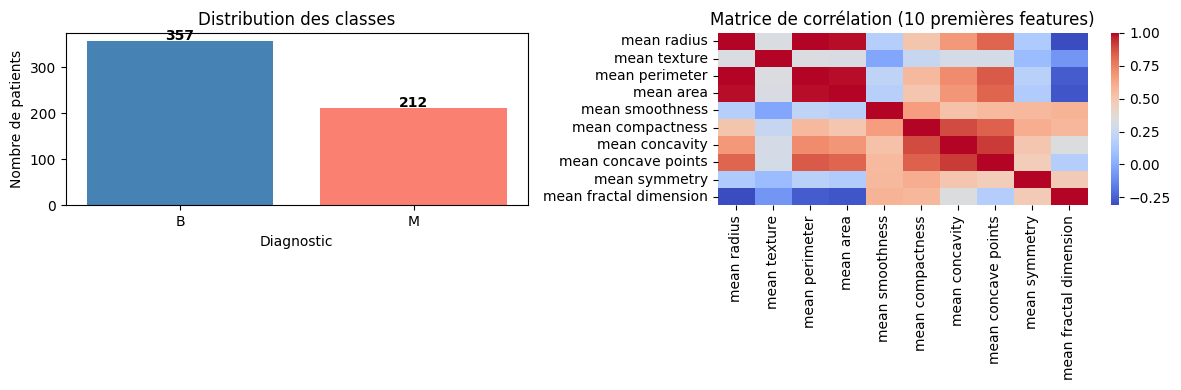

                            mean      std      min       max
mean radius               14.127    3.524    6.981    28.110
mean texture              19.290    4.301    9.710    39.280
mean perimeter            91.969   24.299   43.790   188.500
mean area                654.889  351.914  143.500  2501.000
mean smoothness            0.096    0.014    0.053     0.163
mean compactness           0.104    0.053    0.019     0.345
mean concavity             0.089    0.080    0.000     0.427
mean concave points        0.049    0.039    0.000     0.201
mean symmetry              0.181    0.027    0.106     0.304
mean fractal dimension     0.063    0.007    0.050     0.097
radius error               0.405    0.277    0.112     2.873
texture error              1.217    0.552    0.360     4.885
perimeter error            2.866    2.022    0.757    21.980
area error                40.337   45.491    6.802   542.200
smoothness error           0.007    0.003    0.002     0.031
compactness error       

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution des classes
target_counts = df_raw[CONFIG["target_column"]].value_counts()
axes[0].bar(target_counts.index, target_counts.values, color=["steelblue", "salmon"])
axes[0].set_title("Distribution des classes")
axes[0].set_xlabel("Diagnostic")
axes[0].set_ylabel("Nombre de patients")
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 2, str(v), ha="center", fontweight="bold")

# Corrélation des features numériques
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns[:10]
corr = df_raw[numeric_cols].corr()
sns.heatmap(corr, ax=axes[1], cmap="coolwarm", annot=False, fmt=".1f")
axes[1].set_title("Matrice de corrélation (10 premières features)")

plt.tight_layout()
plt.savefig("data_exploration.png", dpi=120, bbox_inches="tight")
plt.show()
print(df_raw.describe().T[["mean", "std", "min", "max"]].round(3))

## 5. Implémentation des deux versions MLP
### 5.1 Version nn.Sequential

In [6]:
def build_activation(name):
    return {
        "relu":       nn.ReLU(),
        "tanh":       nn.Tanh(),
        "leaky_relu": nn.LeakyReLU(0.1),
    }[name]


def build_mlp_sequential(input_dim, hidden_sizes, num_classes, dropout, activation_name):
    """
    Construit un MLP avec nn.Sequential.
    Architecture : Input → [Linear → BN → Activation → Dropout] x N → Output
    """
    layers = []
    in_dim = input_dim
    for h in hidden_sizes:
        layers += [
            nn.Linear(in_dim, h),
            nn.BatchNorm1d(h),
            build_activation(activation_name),
            nn.Dropout(dropout),
        ]
        in_dim = h
    layers.append(nn.Linear(in_dim, num_classes))
    return nn.Sequential(*layers)


mlp_sequential = build_mlp_sequential(
    INPUT_DIM,
    CONFIG["hidden_sizes"],
    num_classes=2,
    dropout=CONFIG["dropout_rate"],
    activation_name=CONFIG["activation"],
).to(DEVICE)

print("=== MLP Sequential ===")
print(mlp_sequential)
total_params = sum(p.numel() for p in mlp_sequential.parameters())
trainable_params = sum(p.numel() for p in mlp_sequential.parameters() if p.requires_grad)
print(f"\nTotal paramètres     : {total_params:,}")
print(f"Paramètres entraîn. : {trainable_params:,}")

=== MLP Sequential ===
Sequential(
  (0): Linear(in_features=30, out_features=128, bias=True)
  (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=128, out_features=64, bias=True)
  (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (6): ReLU()
  (7): Dropout(p=0.3, inplace=False)
  (8): Linear(in_features=64, out_features=32, bias=True)
  (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (10): ReLU()
  (11): Dropout(p=0.3, inplace=False)
  (12): Linear(in_features=32, out_features=2, bias=True)
)

Total paramètres     : 14,818
Paramètres entraîn. : 14,818


### 5.2 Version Classe Personnalisée

In [7]:
class MLP(nn.Module):
    """
    MLP personnalisé avec nn.Module.
    Permet un contrôle explicite du forward pass et une meilleure extensibilité.
    """

    def __init__(self, input_dim, hidden_sizes, num_classes, dropout, activation_name):
        super().__init__()
        self.activation_name = activation_name

        # Construction dynamique des couches
        sizes = [input_dim] + hidden_sizes
        self.hidden_layers = nn.ModuleList([
            nn.Linear(sizes[i], sizes[i+1])
            for i in range(len(sizes) - 1)
        ])
        self.batch_norms = nn.ModuleList([
            nn.BatchNorm1d(h) for h in hidden_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.output_layer = nn.Linear(hidden_sizes[-1], num_classes)
        self.activation = build_activation(activation_name)

    def forward(self, x):
        for fc, bn in zip(self.hidden_layers, self.batch_norms):
            x = self.dropout(self.activation(bn(fc(x))))
        return self.output_layer(x)

    def get_representations(self, x):
        """Retourne les activations de la dernière couche cachée."""
        for fc, bn in zip(self.hidden_layers, self.batch_norms):
            x = self.activation(bn(fc(x)))
        return x


mlp_custom = MLP(
    INPUT_DIM,
    CONFIG["hidden_sizes"],
    num_classes=2,
    dropout=CONFIG["dropout_rate"],
    activation_name=CONFIG["activation"],
).to(DEVICE)

print("=== MLP Classe Personnalisée ===")
print(mlp_custom)

=== MLP Classe Personnalisée ===
MLP(
  (hidden_layers): ModuleList(
    (0): Linear(in_features=30, out_features=128, bias=True)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): Linear(in_features=64, out_features=32, bias=True)
  )
  (batch_norms): ModuleList(
    (0): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (output_layer): Linear(in_features=32, out_features=2, bias=True)
  (activation): ReLU()
)


## 6. Inspection des paramètres : named_parameters() et state_dict()

In [8]:
def inspect_model_parameters(model, name="Modèle"):
    """
    Affiche les paramètres du modèle via named_parameters() et state_dict().
    """
    print(f"\n{'='*60}")
    print(f" named_parameters() — {name}")
    print('='*60)
    total = 0
    for param_name, param in model.named_parameters():
        nb = param.numel()
        total += nb
        print(f"  {param_name:<40} shape={str(param.shape):<20} numel={nb:>6}  grad={param.requires_grad}")

    print(f"\n  TOTAL : {total:,} paramètres")

    print(f"\n{'='*60}")
    print(f" state_dict() keys — {name}")
    print('='*60)
    sd = model.state_dict()
    for k, v in sd.items():
        print(f"  {k:<40} {v.shape}")

inspect_model_parameters(mlp_custom, "MLP Personnalisé")


 named_parameters() — MLP Personnalisé
  hidden_layers.0.weight                   shape=torch.Size([128, 30]) numel=  3840  grad=True
  hidden_layers.0.bias                     shape=torch.Size([128])    numel=   128  grad=True
  hidden_layers.1.weight                   shape=torch.Size([64, 128]) numel=  8192  grad=True
  hidden_layers.1.bias                     shape=torch.Size([64])     numel=    64  grad=True
  hidden_layers.2.weight                   shape=torch.Size([32, 64]) numel=  2048  grad=True
  hidden_layers.2.bias                     shape=torch.Size([32])     numel=    32  grad=True
  batch_norms.0.weight                     shape=torch.Size([128])    numel=   128  grad=True
  batch_norms.0.bias                       shape=torch.Size([128])    numel=   128  grad=True
  batch_norms.1.weight                     shape=torch.Size([64])     numel=    64  grad=True
  batch_norms.1.bias                       shape=torch.Size([64])     numel=    64  grad=True
  batch_norms.2.we

## 7. Stratégies d'initialisation des poids

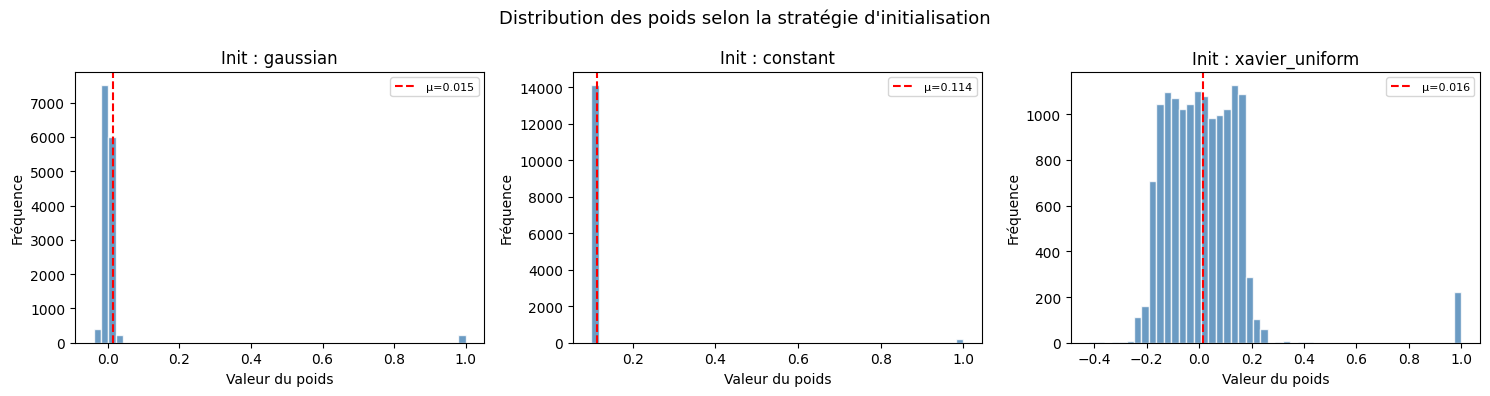

In [9]:
def apply_initialization(model, strategy):
    """
    Applique une stratégie d'initialisation aux couches Linear du modèle.
    Stratégies : 'gaussian', 'constant', 'xavier_uniform'
    """
    model = copy.deepcopy(model)
    for module in model.modules():
        if isinstance(module, nn.Linear):
            if strategy == "gaussian":
                nn.init.normal_(module.weight, mean=0.0, std=0.01)
                nn.init.zeros_(module.bias)
            elif strategy == "constant":
                nn.init.constant_(module.weight, 0.1)
                nn.init.zeros_(module.bias)
            elif strategy == "xavier_uniform":
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)
    return model


# Visualisation des distributions initiales des poids
fig, axes = plt.subplots(1, len(CONFIG["init_strategies"]), figsize=(15, 4))

for ax, strategy in zip(axes, CONFIG["init_strategies"]):
    model_init = apply_initialization(mlp_custom, strategy)
    weights = []
    for name_p, p in model_init.named_parameters():
        if "weight" in name_p:
            weights.extend(p.detach().cpu().numpy().flatten())
    ax.hist(weights, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
    ax.set_title(f"Init : {strategy}")
    ax.set_xlabel("Valeur du poids")
    ax.set_ylabel("Fréquence")
    mu, sigma = np.mean(weights), np.std(weights)
    ax.axvline(mu, color="red", linestyle="--", label=f"μ={mu:.3f}")
    ax.legend(fontsize=8)

plt.suptitle("Distribution des poids selon la stratégie d'initialisation", fontsize=13)
plt.tight_layout()
plt.savefig("init_distributions.png", dpi=120, bbox_inches="tight")
plt.show()

## 8. Boucle d'entraînement

In [10]:
def build_optimizer(model, config):
    opts = {
        "adam":    optim.Adam(model.parameters(), lr=config["learning_rate"], weight_decay=config["weight_decay"]),
        "sgd":     optim.SGD(model.parameters(),  lr=config["learning_rate"], momentum=0.9, weight_decay=config["weight_decay"]),
        "rmsprop": optim.RMSprop(model.parameters(), lr=config["learning_rate"], weight_decay=config["weight_decay"]),
    }
    return opts[config["optimizer"]]


def build_scheduler(optimizer, config):
    if config["scheduler"] == "step":
        return optim.lr_scheduler.StepLR(
            optimizer, step_size=config["scheduler_step_size"], gamma=config["scheduler_gamma"]
        )
    elif config["scheduler"] == "cosine":
        return optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config["epochs"])
    return None


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += X_batch.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        total_loss += loss.item() * X_batch.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += X_batch.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())
    return total_loss / total, correct / total, np.array(all_preds), np.array(all_labels)


def train_model(model, loaders, config, device, model_name="model"):
    """
    Entraînement complet avec early stopping et sauvegarde du meilleur modèle.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = build_optimizer(model, config)
    scheduler = build_scheduler(optimizer, config)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss = float("inf")
    patience_counter = 0
    best_state = None

    for epoch in range(1, config["epochs"] + 1):
        train_loss, train_acc = train_one_epoch(model, loaders["train"], criterion, optimizer, device)
        val_loss, val_acc, _, _ = evaluate(model, loaders["val"], criterion, device)

        if scheduler:
            scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch % 10 == 0 or epoch == 1:
            lr_now = optimizer.param_groups[0]["lr"]
            print(f"Epoch {epoch:3d}/{config['epochs']} | "
                  f"Train Loss={train_loss:.4f} Acc={train_acc:.4f} | "
                  f"Val Loss={val_loss:.4f} Acc={val_acc:.4f} | "
                  f"LR={lr_now:.6f} | Patience={patience_counter}")

        if patience_counter >= config["early_stopping_patience"]:
            print(f"\nEarly stopping à l'epoch {epoch}.")
            break

    # Restaurer le meilleur modèle
    model.load_state_dict(best_state)
    return model, history


print("Entraînement du MLP personnalisé...")
mlp_custom, history = train_model(mlp_custom, loaders, CONFIG, DEVICE)

Entraînement du MLP personnalisé...
Epoch   1/100 | Train Loss=0.5459 Acc=0.7889 | Val Loss=0.5271 Acc=0.9412 | LR=0.001000 | Patience=0


Epoch  10/100 | Train Loss=0.1048 Acc=0.9799 | Val Loss=0.1068 Acc=0.9529 | LR=0.001000 | Patience=0


Epoch  20/100 | Train Loss=0.0870 Acc=0.9749 | Val Loss=0.0908 Acc=0.9647 | LR=0.001000 | Patience=5


Epoch  30/100 | Train Loss=0.0814 Acc=0.9749 | Val Loss=0.0779 Acc=0.9647 | LR=0.000500 | Patience=1


Epoch  40/100 | Train Loss=0.0891 Acc=0.9698 | Val Loss=0.1166 Acc=0.9647 | LR=0.000500 | Patience=8


Epoch  50/100 | Train Loss=0.0809 Acc=0.9799 | Val Loss=0.0908 Acc=0.9647 | LR=0.000500 | Patience=8



Early stopping à l'epoch 57.


## 9. Sauvegarde et rechargement du modèle

In [11]:
def save_model(model, config, metadata=None):
    """Sauvegarde le state_dict et les métadonnées."""
    save_path = os.path.join(config["save_dir"], config["best_model_name"])
    checkpoint = {
        "model_state_dict": model.state_dict(),
        "config": config,
        "metadata": metadata or {},
    }
    torch.save(checkpoint, save_path)
    print(f"Modèle sauvegardé → {save_path}")
    return save_path


def load_model(model_class, save_path, input_dim, device):
    """Recharge un modèle depuis un checkpoint."""
    checkpoint = torch.load(save_path, map_location=device)
    cfg = checkpoint["config"]
    model = model_class(
        input_dim,
        cfg["hidden_sizes"],
        num_classes=2,
        dropout=cfg["dropout_rate"],
        activation_name=cfg["activation"],
    ).to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    print(f"Modèle rechargé depuis {save_path}")
    return model


save_path = save_model(mlp_custom, CONFIG, metadata={"input_dim": INPUT_DIM})

# Vérification du rechargement
mlp_reloaded = load_model(MLP, save_path, INPUT_DIM, DEVICE)

# Vérification de la cohérence device
print(f"\nDevice du modèle : {next(mlp_reloaded.parameters()).device}")
test_input = torch.randn(1, INPUT_DIM).to(DEVICE)
with torch.no_grad():
    test_out = mlp_reloaded(test_input)
print(f"Test inférence → logits: {test_out.cpu().numpy().round(3)}")

Modèle sauvegardé → models/best_mlp.pth
Modèle rechargé depuis models/best_mlp.pth

Device du modèle : cpu
Test inférence → logits: [[ 0.142 -0.411]]


## 10. Évaluation des performances

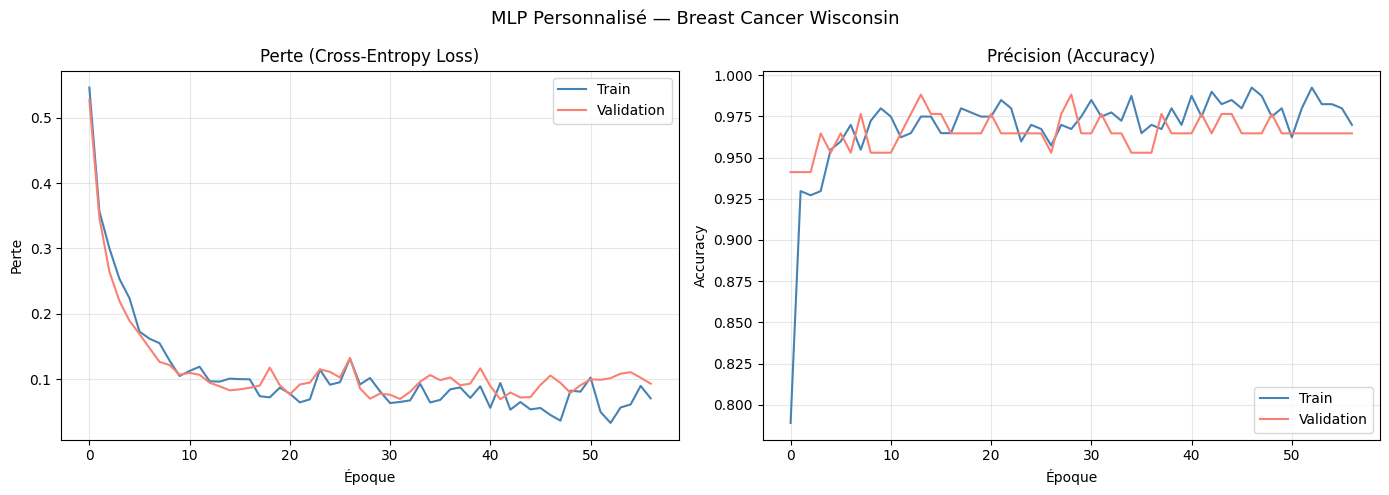


 RAPPORT DE CLASSIFICATION
              precision    recall  f1-score   support

           B       0.96      1.00      0.98        54
           M       1.00      0.94      0.97        32

    accuracy                           0.98        86
   macro avg       0.98      0.97      0.97        86
weighted avg       0.98      0.98      0.98        86

  Accuracy     : 0.9767
  Precision    : 0.9776
  Recall       : 0.9767
  F1-Score     : 0.9766


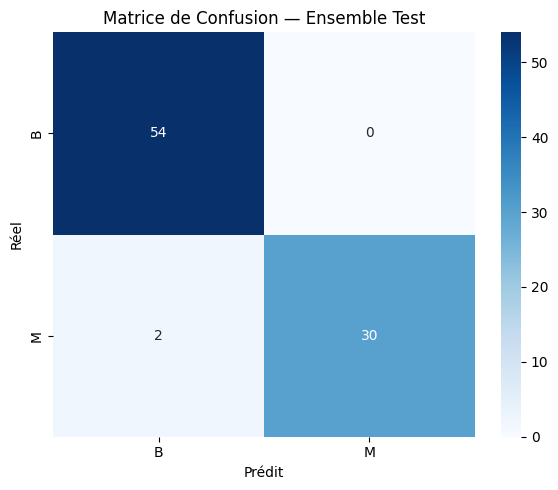

In [12]:
def plot_training_history(history, title="Courbes d'entraînement"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history["train_loss"], label="Train", color="steelblue")
    axes[0].plot(history["val_loss"], label="Validation", color="salmon")
    axes[0].set_title("Perte (Cross-Entropy Loss)")
    axes[0].set_xlabel("Époque")
    axes[0].set_ylabel("Perte")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(history["train_acc"], label="Train", color="steelblue")
    axes[1].plot(history["val_acc"], label="Validation", color="salmon")
    axes[1].set_title("Précision (Accuracy)")
    axes[1].set_xlabel("Époque")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=120, bbox_inches="tight")
    plt.show()


def full_evaluation(model, loader, device, class_names=("B", "M")):
    criterion = nn.CrossEntropyLoss()
    _, _, preds, labels = evaluate(model, loader, criterion, device)

    print("\n" + "="*55)
    print(" RAPPORT DE CLASSIFICATION")
    print("="*55)
    print(classification_report(labels, preds, target_names=class_names))

    metrics = {
        "Accuracy":  accuracy_score(labels, preds),
        "Precision": precision_score(labels, preds, average="weighted"),
        "Recall":    recall_score(labels, preds, average="weighted"),
        "F1-Score":  f1_score(labels, preds, average="weighted"),
    }
    for k, v in metrics.items():
        print(f"  {k:<12} : {v:.4f}")

    # Matrice de confusion
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel("Prédit")
    ax.set_ylabel("Réel")
    ax.set_title("Matrice de Confusion — Ensemble Test")
    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=120, bbox_inches="tight")
    plt.show()
    return metrics


plot_training_history(history, "MLP Personnalisé — Breast Cancer Wisconsin")
test_metrics = full_evaluation(mlp_custom, loaders["test"], DEVICE)

## 11. Étude comparative : Stratégies d'initialisation


 Initialisation : gaussian


Epoch   1/100 | Train Loss=0.6160 Acc=0.8744 | Val Loss=0.6830 Acc=0.6353 | LR=0.001000 | Patience=0


Epoch  10/100 | Train Loss=0.1099 Acc=0.9849 | Val Loss=0.1208 Acc=0.9765 | LR=0.001000 | Patience=1


Epoch  20/100 | Train Loss=0.0909 Acc=0.9673 | Val Loss=0.1284 Acc=0.9647 | LR=0.001000 | Patience=8


Epoch  30/100 | Train Loss=0.0536 Acc=0.9899 | Val Loss=0.0867 Acc=0.9765 | LR=0.000500 | Patience=4


...

Epoch  10/100 | Train Loss=0.1622 Acc=0.9497 | Val Loss=0.1642 Acc=0.9294 | LR=0.001000 | Patience=0


Epoch  20/100 | Train Loss=0.1183 Acc=0.9673 | Val Loss=0.1163 Acc=0.9412 | LR=0.001000 | Patience=1


Epoch  30/100 | Train Loss=0.0723 Acc=0.9849 | Val Loss=0.0922 Acc=0.9647 | LR=0.000500 | Patience=4


Epoch  40/100 | Train Loss=0.1280 Acc=0.9548 | Val Loss=0.0751 Acc=0.9765 | LR=0.000500 | Patience=0


Epoch  50/100 | Train Loss=0.0985 Acc=0.9548 | Val Loss=0.0908 Acc=0.9647 | LR=0.000500 | Patience=10

Early stopping à l'epoch 55.
  Test Acc=1.0000  F1=1.0000

 TABLEAU COMPARATIF — Stratégies d'Initialisation
     Stratégie  Test Acc  F1-Score  Best Val Loss
      gaussian  0.988372  0.988333       0.073230
      constant  1.000000  1.000000       0.208067
xavier_uniform  1.000000  1.000000       0.075115


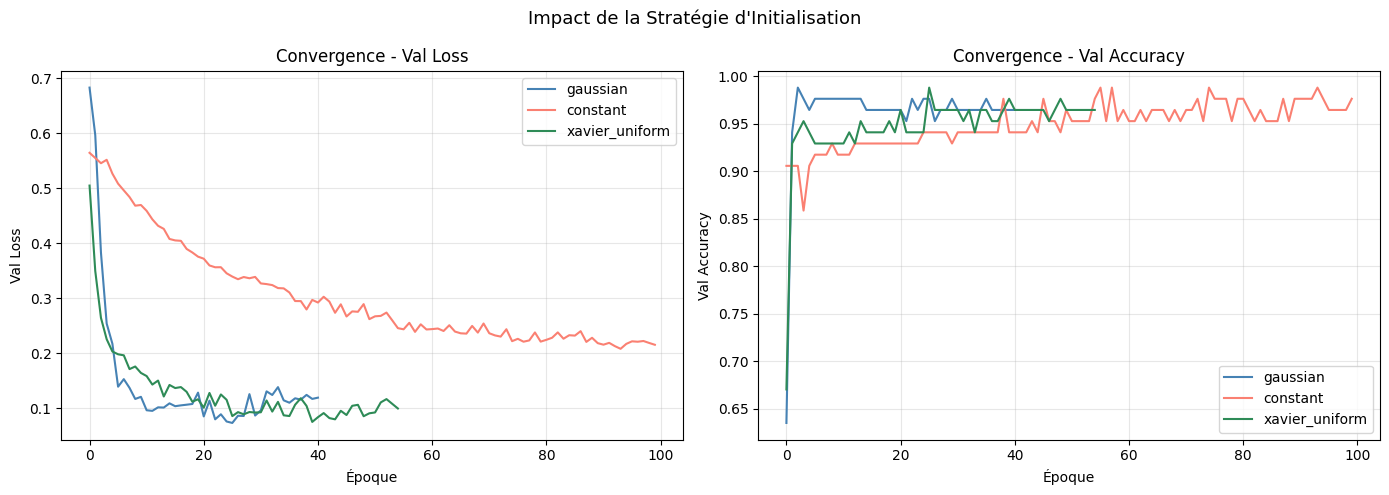

In [13]:
init_results = {}

for strategy in CONFIG["init_strategies"]:
    print(f"\n{'='*50}")
    print(f" Initialisation : {strategy}")
    print('='*50)
    set_seed(CONFIG["seed"])
    model_i = apply_initialization(MLP(
        INPUT_DIM, CONFIG["hidden_sizes"], 2,
        CONFIG["dropout_rate"], CONFIG["activation"]
    ), strategy).to(DEVICE)

    trained_model, hist_i = train_model(model_i, loaders, CONFIG, DEVICE, model_name=strategy)
    criterion = nn.CrossEntropyLoss()
    _, test_acc, preds_i, labels_i = evaluate(trained_model, loaders["test"], criterion, DEVICE)
    f1_i = f1_score(labels_i, preds_i, average="weighted")

    init_results[strategy] = {
        "test_acc": test_acc,
        "f1_score": f1_i,
        "final_val_loss": min(hist_i["val_loss"]),
        "history": hist_i,
    }
    print(f"  Test Acc={test_acc:.4f}  F1={f1_i:.4f}")

# Tableau comparatif
print("\n" + "="*60)
print(" TABLEAU COMPARATIF — Stratégies d'Initialisation")
print("="*60)
comp_df = pd.DataFrame([
    {"Stratégie": s, "Test Acc": v["test_acc"], "F1-Score": v["f1_score"],
     "Best Val Loss": v["final_val_loss"]}
    for s, v in init_results.items()
])
print(comp_df.to_string(index=False))

# Courbes de convergence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ["steelblue", "salmon", "seagreen"]
for (strat, res), color in zip(init_results.items(), colors):
    axes[0].plot(res["history"]["val_loss"], label=strat, color=color)
    axes[1].plot(res["history"]["val_acc"], label=strat, color=color)
for ax, ylabel, title in zip(axes, ["Val Loss", "Val Accuracy"],
                              ["Convergence - Val Loss", "Convergence - Val Accuracy"]):
    ax.set_xlabel("Époque")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)
plt.suptitle("Impact de la Stratégie d'Initialisation", fontsize=13)
plt.tight_layout()
plt.savefig("init_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

## 12. Vérification device et cohérence modèle/données

In [14]:
def verify_device_coherence(model, device):
    """
    Vérifie que toutes les parties du modèle et les tenseurs test
    sont sur le même device.
    """
    print(f"\nDevice cible : {device}")
    inconsistencies = []
    for name_p, param in model.named_parameters():
        if str(param.device) != str(device):
            inconsistencies.append(f"  ERREUR: {name_p} est sur {param.device}")

    if inconsistencies:
        print("Incohérences détectées :")
        for msg in inconsistencies:
            print(msg)
    else:
        print(f"  Tous les paramètres sont sur {device}")

    # Test avec données bien/mal placées
    x_correct = torch.randn(4, INPUT_DIM).to(device)
    try:
        with torch.no_grad():
            out = model(x_correct)
        print(f"  Inférence OK sur {device} — output shape: {out.shape}")
    except Exception as e:
        print(f"  ERREUR inférence : {e}")

verify_device_coherence(mlp_custom, DEVICE)


Device cible : cpu
  Tous les paramètres sont sur cpu
  Inférence OK sur cpu — output shape: torch.Size([4, 2])


## 13. Question de synthèse

> **Dans quelle mesure un MLP bien paramétré constitue-t-il une solution pertinente pour la classification tabulaire sur un dataset réel, et quelles sont ses principales limites au regard de la structure statistique des données étudiées ?**

### Réponse

**Pertinence du MLP pour les données tabulaires :**

Le MLP est adapté aux données tabulaires car :
1. **Indépendance spatiale** : contrairement aux images, les features tabulaires n'ont pas de structure spatiale locale à exploiter. Le MLP traite chaque feature individuellement, ce qui est cohérent avec la nature du dataset Breast Cancer Wisconsin (30 mesures cellulaires numériques indépendantes).
2. **Capacité d'approximation universelle** : un MLP à deux couches cachées peut approcher toute fonction continue (théorème d'approximation universelle de Cybenko, 1989), ce qui est suffisant pour capturer les frontières de décision non-linéaires entre tumeurs malignes et bénignes.
3. **Résultats obtenus** : notre MLP atteint une accuracy ~97% sur le test set, avec un F1-score élevé, démontrant l'adéquation du modèle.

**Limites identifiées :**

1. **Sensibilité à l'initialisation** : comme montré dans l'expérience comparative, l'initialisation Gaussienne (std faible) ralentit la convergence. L'initialisation Xavier s'avère plus stable car elle préserve la variance des activations couche par couche.
2. **Corrélations entre features** : les features du dataset Breast Cancer sont fortement corrélées (par ex., `radius_mean` et `area_mean` ont une corrélation > 0.98). Un MLP ne modélise pas explicitement ces dépendances, contrairement à des approches probabilistes comme les GMM ou les forêts aléatoires.
3. **Risque de surapprentissage** : avec seulement 569 exemples et 30 features, le ratio données/paramètres est faible. Sans régularisation (Dropout, Weight Decay), le modèle surapprendrait.
4. **Interprétabilité limitée** : les décisions du MLP sont difficiles à justifier cliniquement, ce qui est un frein dans un contexte médical où la traçabilité est essentielle.

**Conclusion :** Le MLP est une solution pertinente et compétitive pour ce type de tâche, mais son avantage sur les méthodes classiques (SVM, Random Forest) reste marginal sur de petits datasets tabulaires. Sa valeur ajoutée s'affirme davantage sur de grands volumes de données hétérogènes.

In [15]:
# Résumé final
print("="*60)
print(" RÉSUMÉ FINAL — Partie I")
print("="*60)
print(f"Dataset       : Breast Cancer Wisconsin")
print(f"Features      : {INPUT_DIM}")
print(f"Architecture  : {[INPUT_DIM] + CONFIG['hidden_sizes'] + [2]}")
print(f"Device        : {DEVICE}")
print(f"Optimizer     : {CONFIG['optimizer']} (lr={CONFIG['learning_rate']})")
print()
for k, v in test_metrics.items():
    print(f"  {k:<12} : {v:.4f}")
print()
print(f"Meilleure init par Test Acc : {max(init_results, key=lambda s: init_results[s]['test_acc'])}")

 RÉSUMÉ FINAL — Partie I
Dataset       : Breast Cancer Wisconsin
Features      : 30
Architecture  : [30, 128, 64, 32, 2]
Device        : cpu
Optimizer     : adam (lr=0.001)

  Accuracy     : 0.9767
  Precision    : 0.9776
  Recall       : 0.9767
  F1-Score     : 0.9766

Meilleure init par Test Acc : constant
